In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Hemos estimado parámetros de una distribución a partir de una muestra en el Notebook 03. Sin embargo, en los Notebooks 01 y 02 hemos visto que distintas muestras pueden producir estimaciones diferentes, y que esta variabilidad depende, entre otras cosas, del tamaño de la muestra.

Como ingenieros, puede ser interesante **cuantificar esta incertidumbre**, para poder valorar con mayor confianza los resultados y tomar mejores decisiones.

En este caso, en lugar de proporcionar únicamente una estimación puntual, podemos proporcionar un **intervalo de confianza** asociado a un determinado nivel de confianza.

Por ejemplo, para un nivel de confianza del 95 % (\(\alpha=5\%\)), el procedimiento utilizado para construir el intervalo está diseñado de forma que, si repitiésemos el proceso de muestreo y construcción del intervalo muchas veces, aproximadamente el 95 % de los intervalos obtenidos contendrían el verdadero valor del parámetro.

Las herramientas matemáticas necesarias para calcular estos intervalos quedan fuera del objetivo de este curso. El método dependerá de qué queramos estimar y de las hipótesis que podamos asumir sobre nuestros datos.

En este notebook veremos algunos ejemplos sencillos para **una probabilidad, una media y una varianza**, con el objetivo de entender cómo podemos pasar de una estimación puntual a una estimación acompañada de su incertidumbre.


#### 01 Probabilidad de lluvia

In [19]:
precip = pd.read_csv("/workspaces/AnaliticaDeDatos/datos/clases/clase_3_probabilidad_e_inferencia/rainAEMET005_24h_1981-2022_promedio_Anllons.csv", sep=";", decimal=".")
precip['Date'] = pd.to_datetime(precip['Date'], format="%d/%m/%Y %H:%M")
precip['Date'] = precip['Date'].dt.normalize()
precip = precip.set_index('Date')
precip.index.name = 'time'

In [20]:
precip["Bernoulli"] = (precip["Promedio (mm)"] > 5).astype(int)

precip.head()

,Promedio (mm),Bernoulli
time,,
1981-01-01,0.0090,0
1981-01-02,0.0000,0
1981-01-03,0.0010,0
1981-01-04,0.9195,0
1981-01-05,0.0005,0


In [21]:
p_lluvia = precip["Bernoulli"].mean()

print(f"Probabilidad estimada de lluvia: {p_lluvia:.2%}")

Probabilidad estimada de lluvia: 23.25%


In [22]:
def intervalo_proporcion(p, n, confianza=0.95):

    z = 1.96  # 95 %

    denominador = 1 + z**2 / n

    centro = (
        p + z**2 / (2*n)
    ) / denominador

    margen = (
        z * np.sqrt(
            p * (1-p) / n
            + z**2 / (4*n**2)
        )
    ) / denominador

    return centro - margen, centro + margen

In [23]:
p_lluvia = precip["Bernoulli"].mean()
n = precip["Bernoulli"].count()

inferior, superior = intervalo_proporcion(p_lluvia, n)

print(f"Probabilidad estimada de lluvia: {p_lluvia:.2%}")
print(f"IC 95 %: [{inferior:.2%}, {superior:.2%}]")

Probabilidad estimada de lluvia: 23.25%
IC 95 %: [22.59%, 23.93%]


In [24]:
precip['Year'] = precip.index.year
years = precip.Year.unique()

In [32]:
resultados = []

for y in years:

    data_aux = precip[precip["Year"] == y]

    p_lluvia = data_aux["Bernoulli"].mean()
    n = data_aux["Bernoulli"].count()

    inferior, superior = intervalo_proporcion(
        p_lluvia,
        n,
        confianza=0.95
    )

    resultados.append(
        [y, p_lluvia, inferior, superior, n]
    )

In [33]:
resultados = pd.DataFrame(
    resultados,
    columns=[
        "Año",
        "Probabilidad",
        "Inferior",
        "Superior",
        "n"
    ]
)

resultados

,Año,Probabilidad,Inferior,Superior,n
0,1981,0.202740,0.164689,0.246983,365
1,1982,0.227397,0.187366,0.273107,365
2,1983,0.273973,0.230750,0.321904,365
3,1984,0.286885,0.242948,0.335250,366
4,1985,0.235616,0.194972,0.281768,365
5,1986,0.246575,0.205148,0.293282,365
6,1987,0.238356,0.197512,0.284650,365
7,1988,0.218579,0.179280,0.263724,366
8,1989,0.205479,0.167197,0.249897,365
9,1990,0.219178,0.179782,0.264423,365


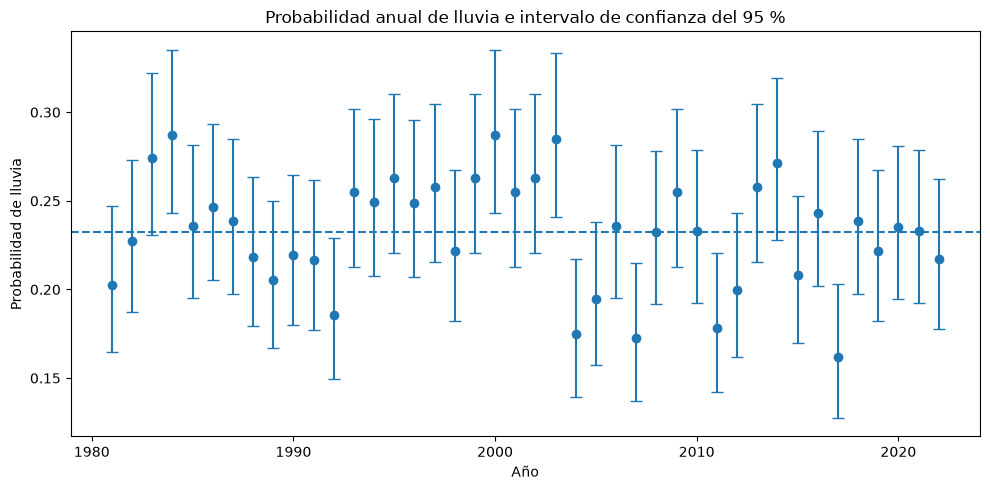

In [34]:
plt.figure(figsize=(10, 5))

plt.errorbar(
    resultados["Año"],
    resultados["Probabilidad"],
    yerr=[
        resultados["Probabilidad"] - resultados["Inferior"],
        resultados["Superior"] - resultados["Probabilidad"]
    ],
    fmt="o",
    capsize=4
)

p_real = precip["Bernoulli"].mean()

plt.axhline(
    p_real,
    linestyle="--",
    label="Probabilidad de referencia"
)

plt.xlabel("Año")
plt.ylabel("Probabilidad de lluvia")
plt.title("Probabilidad anual de lluvia e intervalo de confianza del 95 %")

plt.tight_layout()
plt.show()

In [35]:
precip["periodo"] = (precip["Year"] // 5) * 5

precip[["Year", "periodo"]].head()

,Year,periodo
time,,
1981-01-01,1981,1980
1981-01-02,1981,1980
1981-01-03,1981,1980
1981-01-04,1981,1980
1981-01-05,1981,1980


In [36]:
resultados = []

for periodo, data_aux in precip.groupby("periodo"):

    p_lluvia = data_aux["Bernoulli"].mean()
    n = data_aux["Bernoulli"].count()

    inferior, superior = intervalo_proporcion(
        p_lluvia,
        n
    )

    resultados.append(
        [periodo, p_lluvia, inferior, superior, n]
    )

resultados = pd.DataFrame(
    resultados,
    columns=[
        "Periodo",
        "Probabilidad",
        "Inferior",
        "Superior",
        "n"
    ]
)

resultados

,Periodo,Probabilidad,Inferior,Superior,n
0,1980,0.247775,0.226318,0.270556,1461
1,1985,0.228916,0.210226,0.248744,1826
2,1990,0.225082,0.206515,0.244804,1826
3,1995,0.250821,0.231476,0.271214,1826
4,2000,0.252874,0.233475,0.273309,1827
5,2005,0.217963,0.199629,0.237481,1826
6,2010,0.227820,0.209165,0.247618,1826
7,2015,0.214677,0.196453,0.234099,1826
8,2020,0.228311,0.204424,0.254097,1095


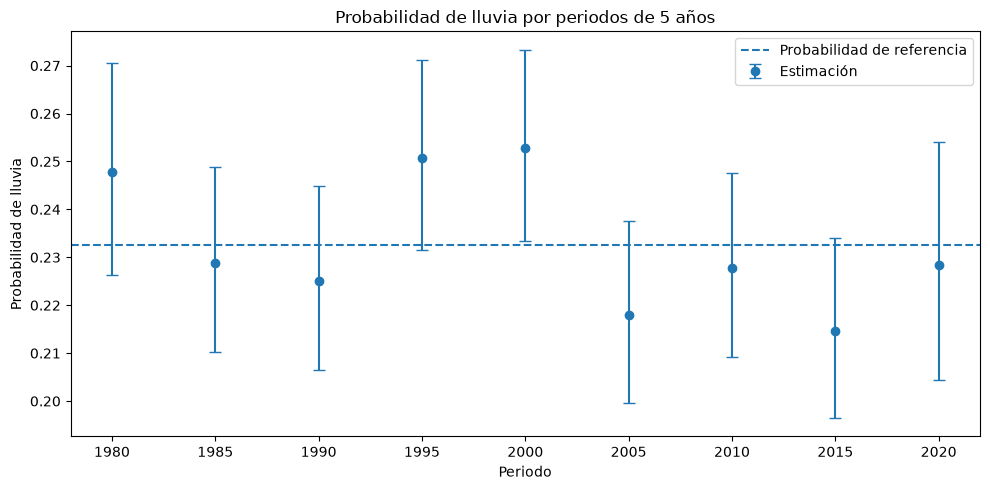

In [37]:
plt.figure(figsize=(10, 5))

plt.errorbar(
    resultados["Periodo"],
    resultados["Probabilidad"],
    yerr=[
        resultados["Probabilidad"] - resultados["Inferior"],
        resultados["Superior"] - resultados["Probabilidad"]
    ],
    fmt="o",
    capsize=4,
    label="Estimación"
)

p_real = precip["Bernoulli"].mean()

plt.axhline(
    p_real,
    linestyle="--",
    label="Probabilidad de referencia"
)

plt.xlabel("Periodo")
plt.ylabel("Probabilidad de lluvia")
plt.title("Probabilidad de lluvia por periodos de 5 años")
plt.legend()

plt.tight_layout()
plt.show()

#### 02 Media de una distribución

In [40]:
media = precip["Promedio (mm)"].mean()

print(f"Precipitación media: {media:.2f} mm")

Precipitación media: 3.57 mm


In [41]:
from scipy.stats import t
import numpy as np

def intervalo_media(datos, confianza=0.95):

    datos = datos.dropna()

    n = len(datos)
    media = datos.mean()
    s = datos.std(ddof=1)

    alpha = 1 - confianza
    t_critico = t.ppf(1 - alpha/2, df=n-1)

    margen = t_critico * s / np.sqrt(n)

    return media - margen, media + margen

In [43]:
media = precip["Promedio (mm)"].mean()

inferior, superior = intervalo_media(
    precip["Promedio (mm)"]
)

print(f"Media estimada: {media:.2f} mm")
print(f"IC 95 %: [{inferior:.2f}, {superior:.2f}] mm")

Media estimada: 3.57 mm
IC 95 %: [3.47, 3.67] mm


In [45]:
resultados = []

for periodo, data_aux in precip.groupby("periodo"):

    datos = data_aux["Promedio (mm)"].dropna()

    media = datos.mean()
    inferior, superior = intervalo_media(datos)

    resultados.append(
        [periodo, media, inferior, superior, len(datos)]
    )

resultados = pd.DataFrame(
    resultados,
    columns=[
        "Periodo",
        "Media",
        "Inferior",
        "Superior",
        "n"
    ]
)

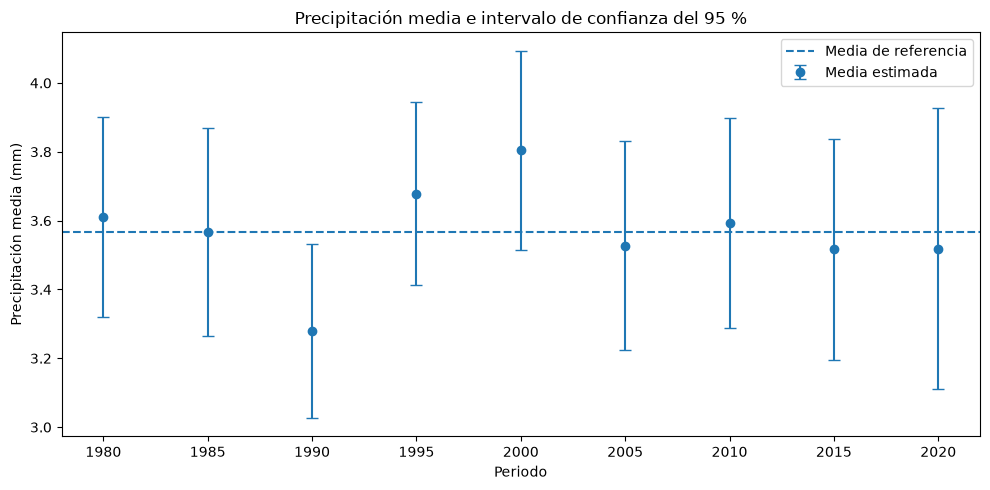

In [47]:
plt.figure(figsize=(10, 5))

plt.errorbar(
    resultados["Periodo"],
    resultados["Media"],
    yerr=[
        resultados["Media"] - resultados["Inferior"],
        resultados["Superior"] - resultados["Media"]
    ],
    fmt="o",
    capsize=4,
    label="Media estimada"
)

media_referencia = precip["Promedio (mm)"].mean()

plt.axhline(
    media_referencia,
    linestyle="--",
    label="Media de referencia"
)

plt.xlabel("Periodo")
plt.ylabel("Precipitación media (mm)")
plt.title("Precipitación media e intervalo de confianza del 95 %")
plt.legend()

plt.tight_layout()
plt.show()

#### 03 Varianza

In [48]:
from scipy.stats import chi2
import numpy as np

def intervalo_varianza(datos, confianza=0.95):

    datos = datos.dropna()

    n = len(datos)
    varianza = datos.var(ddof=1)

    alpha = 1 - confianza

    chi2_inf = chi2.ppf(alpha / 2, df=n-1)
    chi2_sup = chi2.ppf(1 - alpha / 2, df=n-1)

    inferior = (n-1) * varianza / chi2_sup
    superior = (n-1) * varianza / chi2_inf

    return inferior, superior

In [49]:
datos = precip["Promedio (mm)"].dropna()

varianza = datos.var(ddof=1)

inferior, superior = intervalo_varianza(datos)

print(f"Varianza estimada: {varianza:.2f}")
print(f"IC 95 %: [{inferior:.2f}, {superior:.2f}]")

Varianza estimada: 40.18
IC 95 %: [39.30, 41.10]
